# Q6 — Does inconsistency increase for less popular restaurants?

Bins multi-platform venues by **Google review count** (widest, most complete popularity
signal) and reports the **mean** spread per bin with its standard error. Median is
deliberately dropped: with at most three platforms a per-venue range is the max−min of ≤3
values, so a binned median snaps to a few discrete values and tells no story — the mean
(with a confidence band) does.

In [1]:
from analysis.notebook import *

Connected to ClickHouse db='dataman' at localhost:8123


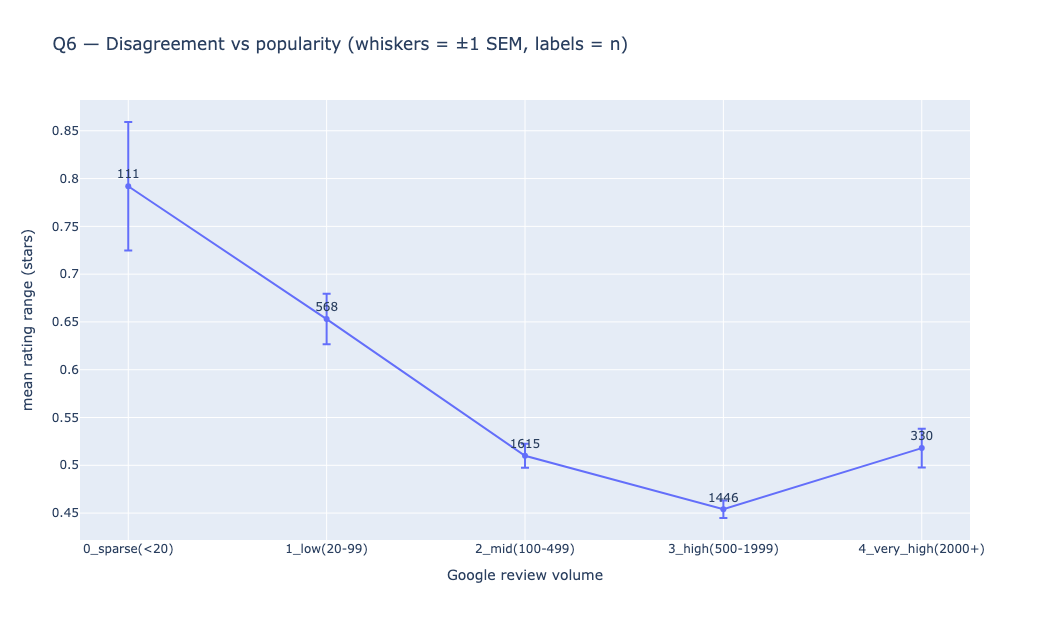

,popularity_bin,restaurants,mean_range,sd_range,sem
0,0_sparse(<20),111,0.792,0.708,0.067200
1,1_low(20-99),568,0.653,0.629,0.026392
2,2_mid(100-499),1615,0.510,0.502,0.012492
3,3_high(500-1999),1446,0.454,0.348,0.009152
4,4_very_high(2000+),330,0.518,0.367,0.020203


In [2]:
q6 = run(queries.q6_popularity_bins())
q6["sem"] = q6["sd_range"] / np.sqrt(q6["restaurants"])
publish(q6, "q6_popularity_bins", "Q6 — Mean rating spread by Google-review popularity bin.")
fig = px.line(q6, x="popularity_bin", y="mean_range", error_y="sem", markers=True, text="restaurants",
              labels={"popularity_bin": "Google review volume", "mean_range": "mean rating range (stars)"},
              title="Q6 — Disagreement vs popularity (whiskers = ±1 SEM, labels = n)")
fig.update_traces(textposition="top center")
fig.show()
q6

**Answer (Q6):** Mean spread **declines as popularity rises** — the sparse/low-review
bins disagree most and the very-high bin least — so inconsistency does increase for smaller,
less-popular restaurants. The SEM band shows the trend is well-determined despite the small
high-popularity bins.